Notes(What needs to be done): 
1. for claim frequency Check var/ mean ratio(Coefficent of variation) to narrow candidates (initial list: Poisson, Negative Binomial, Binomial, Zero-Inflated Poisson, Zero inflated negative binomial, Poisson-Inverse Gaussian)
2. check what predictors are available at underwriting time(not rating)
etc

# 04 - Frequency

**Purpose:** Model claim frequency for each of the four coverages. Covers the
marginal count distribution, one-way frequency relationships, and the fitted
Poisson GLM with validation.

**Input:** `data/processed/frequency_data.csv`
**Output:** Figures to `outputs/figures/`. Fitted model objects held in memory.
**Depends on:** 02_Cleaned_Data, 03_Exploratory_Data_Analysis

**Sections**

1. Marginal distribution of `claim_count` by coverage
2. Distribution family selection (dispersion, zeros, AIC/BIC, GOF)
3. One-way frequency by predictor
4. Credibility: claim counts per cell
5. Poisson GLM fitting and variable selection
6. Validation on the holdout set

**Author:** Dalton | **Last run:** 2026-09-26

analyze var / mean and get candidate distibutions

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
PROC = ROOT / "data" / "processed"
FIGS = ROOT / "outputs" / "figures"

freq = pd.read_csv(PROC / "frequency_data.csv")

COVERAGES = ['Personal Property', 'Additional Living Expense',
             'Guest Medical', 'Liability']

fq = {c: freq[freq.coverage == c].reset_index(drop=True) for c in COVERAGES}

{c: len(d) for c, d in fq.items()}

{'Personal Property': 10000,
 'Additional Living Expense': 10000,
 'Guest Medical': 10000,
 'Liability': 10000}

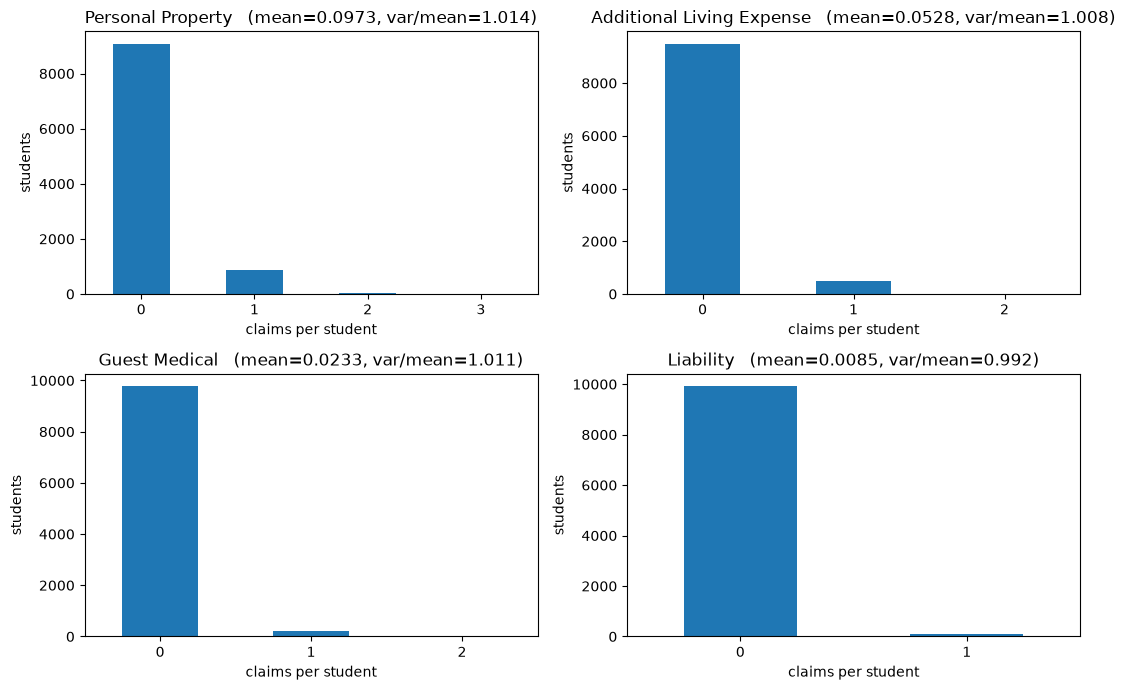

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, cov in zip(axes.flat, COVERAGES):
    d = fq[cov].claim_count
    d.value_counts().sort_index().plot.bar(ax=ax, rot=0, color='#1f77b4')
    ax.set_title(f"{cov}   (mean={d.mean():.4f}, var/mean={d.var()/d.mean():.3f})")
    ax.set_xlabel('claims per student')
    ax.set_ylabel('students')

plt.tight_layout()